In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

import os
os.chdir('/Users/lior/DS6021/DS6021_F26/data')
df = pd.read_csv('PlanetsData.csv')


In [19]:
X = sm.add_constant(df['distance'])
y =df['revolution']
model_lin =sm.OLS(y, X).fit()
print(model_lin.summary())
 
df['pred_revolution'] = model_lin.predict(X)
df['residuals'] = df['revolution'] - df['pred_revolution']
 
print("\nActual vs Predicted (linear model):")
print(df[['planet', 'distance', 'revolution', 'pred_revolution']].round(1))
print("\nNote the four innermost planets (Mercury, Venus, Earth, Mars) "
      "all get NEGATIVE predicted revolutions -- physically impossible!")

                            OLS Regression Results                            
Dep. Variable:             revolution   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     312.1
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           4.59e-07
Time:                        20:57:43   Log-Likelihood:                -88.599
No. Observations:                   9   AIC:                             181.2
Df Residuals:                       7   BIC:                             181.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4578.7935   2287.376     -2.002      0.0

5a

all four inner planets get negative predicted oribital periods. R2 seems to be really high, but this means that we cant reliably look at it for predictions that are sensible.

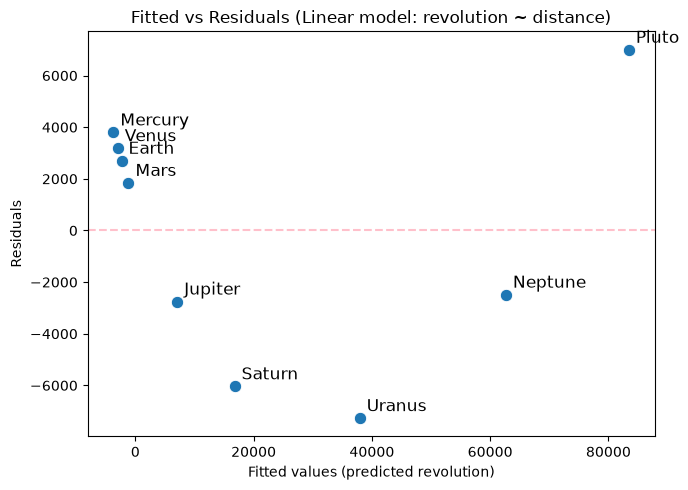

In [21]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='pred_revolution', y='residuals', s=80)
for _, row in df.iterrows():
    plt.annotate(row['planet'], (row['pred_revolution'], row['residuals']),
                 textcoords="offset points", xytext=(5, 5), fontsize=12)
plt.axhline(0, color='pink', linestyle='--')
plt.title('Fitted vs Residuals (Linear model: revolution ~ distance)')
plt.xlabel('Fitted values (predicted revolution)')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

5b

It has a U shape showing that the 4 closest planets have positive residuals, while the rest are negative with the outlier, pluto, going back to being positive. This tells us that its not valid because the relationship between the distance and revolution is curved.

                            OLS Regression Results                            
Dep. Variable:         log_revolution   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.585e+06
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           5.26e-20
Time:                        20:59:11   Log-Likelihood:                 34.696
No. Observations:                   9   AIC:                            -65.39
Df Residuals:                       7   BIC:                            -65.00
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.9031      0.007   -122.147   

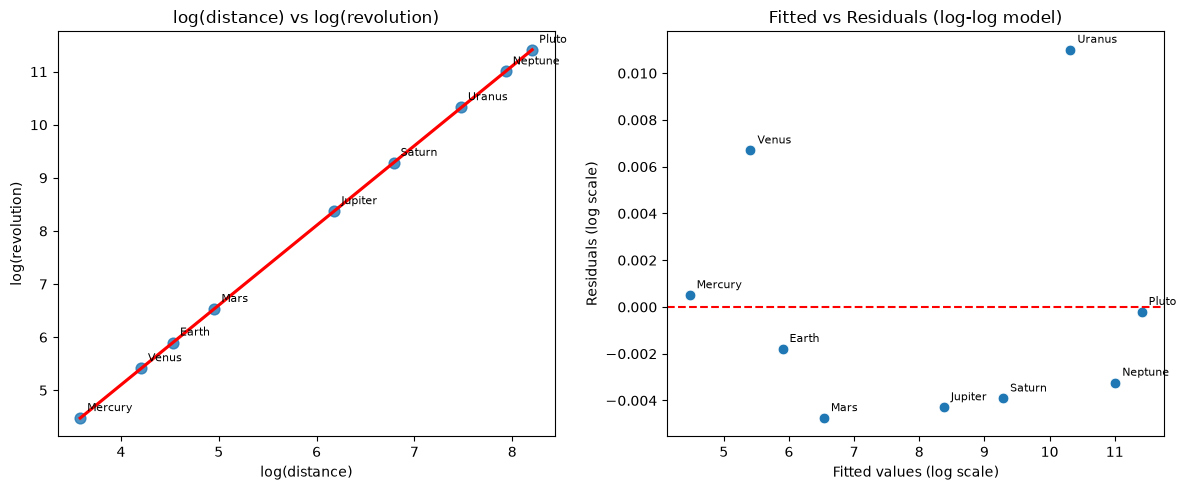

In [22]:

#had to use claude for this part cause i was getting a lot of errors
df['log_distance'] = np.log(df['distance'])
df['log_revolution'] = np.log(df['revolution'])
 
Xlog = sm.add_constant(df['log_distance'])
ylog = df['log_revolution']
model_log = sm.OLS(ylog, Xlog).fit()
print(model_log.summary())
 
df['pred_log_revolution'] = model_log.predict(Xlog)
df['log_residuals'] = df['log_revolution'] - df['pred_log_revolution']
 
slope = model_log.params['log_distance']
intercept = model_log.params['const']
print(f"\nSlope = {slope:.4f}  (~ 3/2)")
print(f"Intercept = {intercept:.4f}")
print(f"R^2 = {model_log.rsquared:.6f}")
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
sns.regplot(data=df, x='log_distance', y='log_revolution', ci=None, ax=axes[0],
            scatter_kws={'s': 60}, line_kws={'color': 'red'})
for _, row in df.iterrows():
    axes[0].annotate(row['planet'], (row['log_distance'], row['log_revolution']),
                      textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[0].set_title('log(distance) vs log(revolution)')
axes[0].set_xlabel('log(distance)')
axes[0].set_ylabel('log(revolution)')
 
sns.scatterplot(data=df, x='pred_log_revolution', y='log_residuals', ax=axes[1], s=60)
for _, row in df.iterrows():
    axes[1].annotate(row['planet'], (row['pred_log_revolution'], row['log_residuals']),
                      textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Fitted vs Residuals (log-log model)')
axes[1].set_xlabel('Fitted values (log scale)')
axes[1].set_ylabel('Residuals (log scale)')
 
plt.tight_layout()
plt.show()

5C - A AND B

Taking the logs of both distance and rev. allows the scattered dowts to fall into a linear line and the fitted vs residuals shows that theres no curve anymore, so this is a much better fit than the first graph

In [23]:
#part c & d
df['pred_revolution_logmodel'] = np.exp(df['pred_log_revolution'])
 
comparison = df[['planet', 'distance', 'revolution','pred_revolution', 'pred_revolution_logmodel']].copy()
comparison.columns = ['planet', 'distance', 'actual_revolution','predicted_revolution (linear model)','predicted_revolution (log-log model)']
print("\nFinal comparison table:")
print(comparison.round(1).to_string(index=False))


Final comparison table:
 planet  distance  actual_revolution  predicted_revolution (linear model)  predicted_revolution (log-log model)
Mercury        36                 88                              -3711.3                                  88.0
  Venus        67                225                              -2964.4                                 223.5
  Earth        93                365                              -2337.9                                 365.7
   Mars       142                687                              -1157.2                                 690.3
Jupiter       484               4332                               7083.5                                4350.6
 Saturn       887              10760                              16794.1                               10802.2
 Uranus      1765              30684                              37950.1                               30348.3
Neptune      2791              60188                              62672.3      

5C - C

the new r2 is 0.999 and the slope is 1.501 (3/2). if we use the slope and log variables, itll give us revolution = e^b0 * distance^3/2, after squaring both sides, it would give keplers 3rd law.

5C - D

The log predictions are almost exact with all of them being within a reasonable range while the linear model was insanely off.